TUTORIAL 11

In [2]:
import pandas as pd #for dataframes
import numpy as np  #for arrays
import seaborn as sns #for visualization of dataset
import matplotlib.pyplot as plt #for visualization
%matplotlib inline


In [3]:
import pandas as pd

train = pd.read_csv("data/titanic_train.csv")
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.isnull() #true means the value is null and false means not null.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
#its hard to study the data this way , so we visualize.

<Axes: >

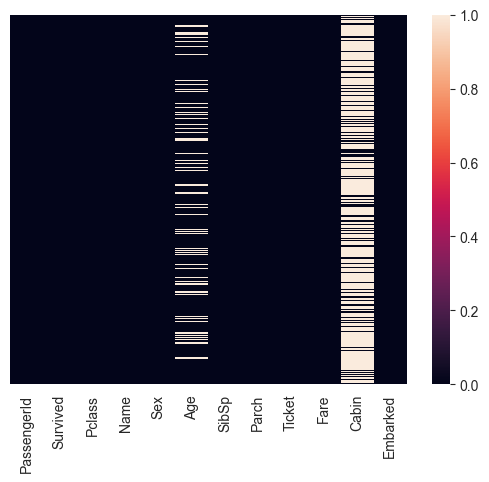

In [6]:
sns.heatmap(train.isnull(), yticklabels = False)  #y axis vanishes )
#dark purple is for null values

<Axes: xlabel='Survived', ylabel='count'>

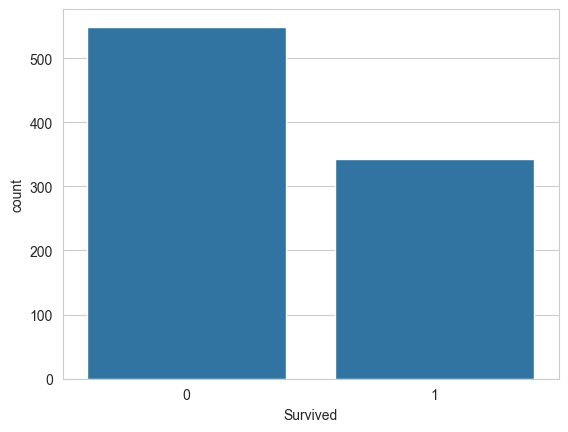

In [7]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived' , data = train)

<Axes: xlabel='Survived', ylabel='count'>

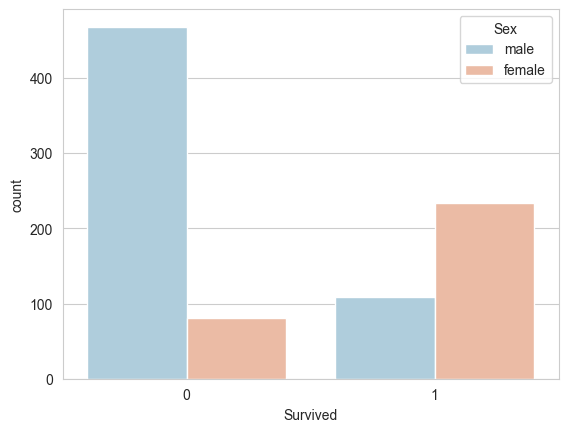

In [8]:
sns.set_style('whitegrid')
sns.countplot( x ='Survived', hue = 'Sex', data = train , palette = 'RdBu_r') #hue is like a sub parameter. it is the countplot of survived divided on the parameter 'sex'

<Axes: xlabel='Survived', ylabel='count'>

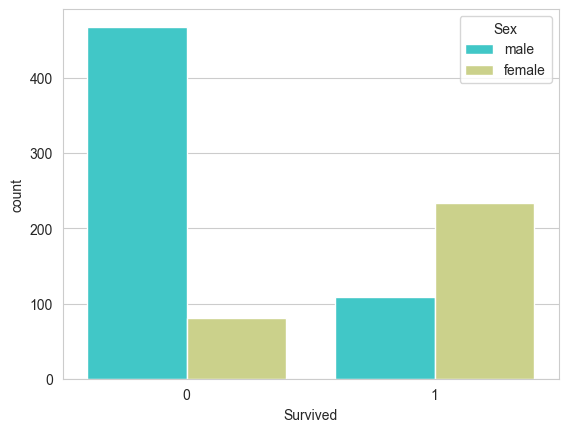

In [9]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived' , hue = 'Sex' , data = train , palette = 'rainbow' )

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_20032/2585634651.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(), kde = False , color = 'darkred', bins = 40)


<Axes: xlabel='Age'>

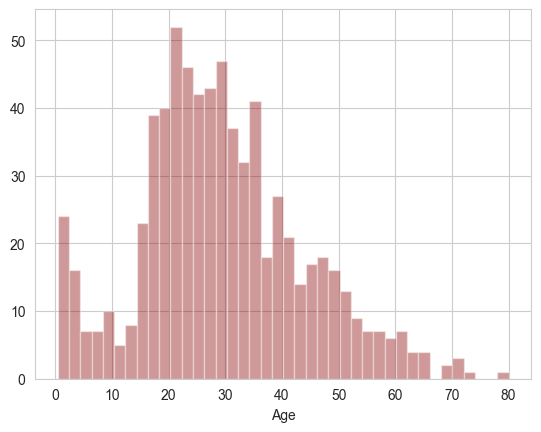

In [10]:
sns.distplot(train['Age'].dropna(), kde = False , color = 'darkred', bins = 40)

<Axes: >

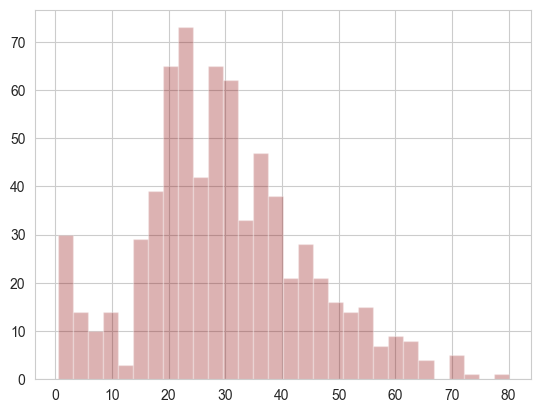

In [11]:
train['Age'].hist(bins = 30, color = 'darkred', alpha = 0.3)


<Axes: xlabel='SibSp', ylabel='count'>

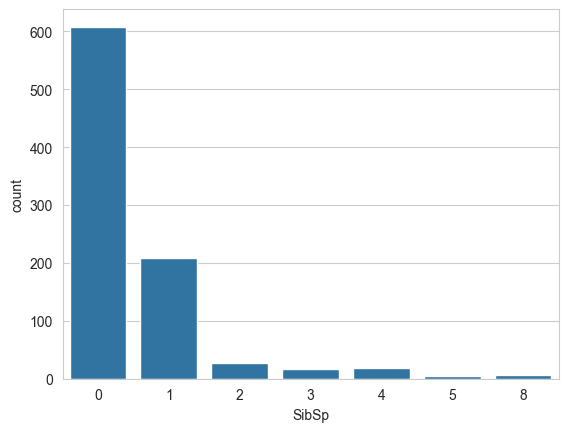

In [12]:
sns.countplot( x = 'SibSp' , data = train)


<Axes: >

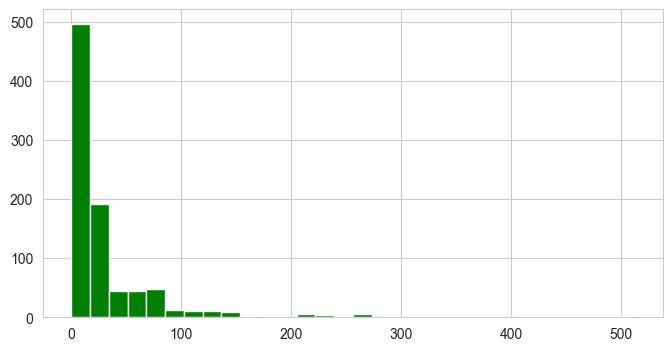

In [13]:
train['Fare'].hist(bins = 30 , color = 'green' , figsize = (8,4))

Data Cleaning

In [14]:
#removing columns

<Axes: xlabel='Pclass', ylabel='Age'>

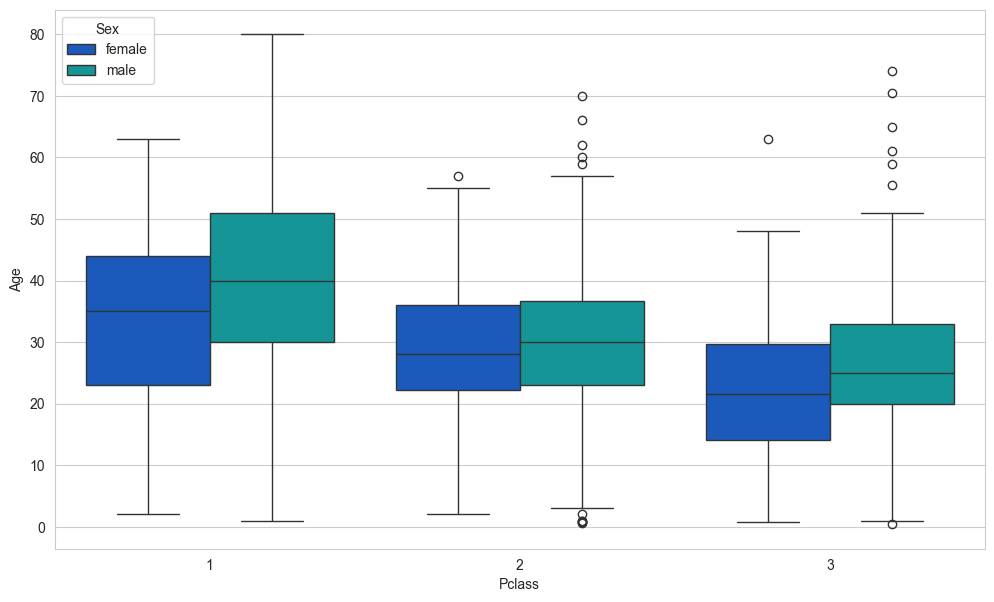

In [15]:
plt.figure(figsize= (12,7))
sns.boxplot(x = 'Pclass' , y = 'Age' , data = train  , hue = 'Sex' ,palette = 'winter')

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_20032/4082328170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Pclass' , y = 'Age' , data = train  , palette = 'winter')


<Axes: xlabel='Pclass', ylabel='Age'>

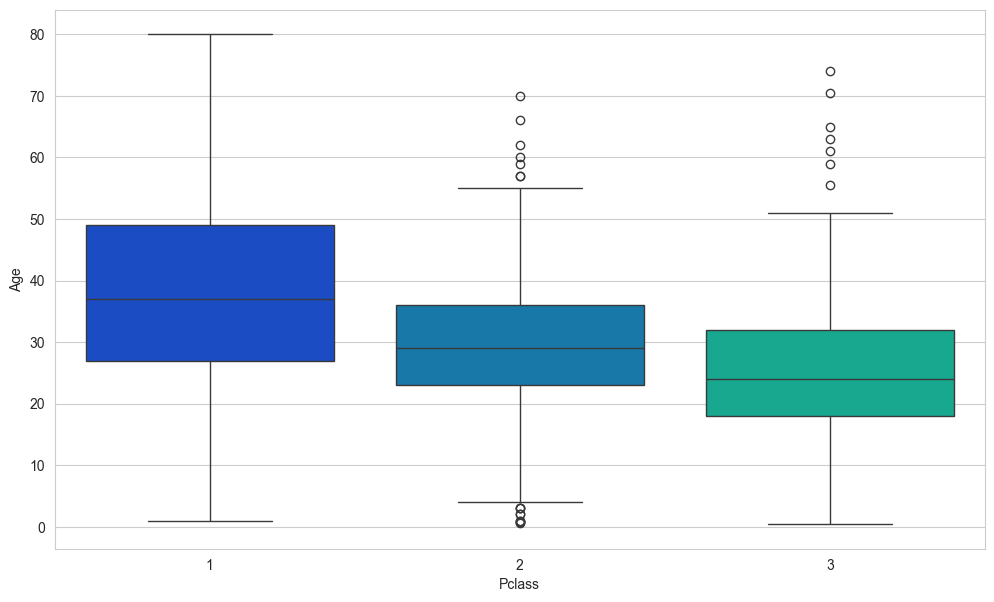

In [16]:
plt.figure(figsize= (12,7))
sns.boxplot(x = 'Pclass' , y = 'Age' , data = train  , palette = 'winter')

In [17]:
def impute_age(cols) :
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age) :
        if Pclass ==1:
            return 37

        elif Pclass == 2 :
            return 29

        else:
            return 24

    else :
        return Age


In [18]:
train['Age'] = train[['Age' , 'Pclass']].apply(impute_age,axis =1)

/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_20032/1608447403.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/var/folders/b6/dbbdf8r51l51p_fc8dv0br_m0000gn/T/ipykernel_20032/1608447403.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


<Axes: >

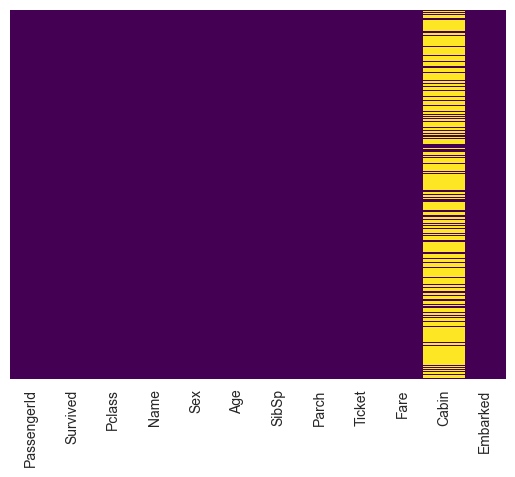

In [19]:
sns.heatmap(train.isnull(), yticklabels = False, cbar = False , cmap = 'viridis')

In [23]:
train.drop('Cabin' ,axis-1, implace= True)
train.head()

NameError: name 'axis' is not defined

CONVERTING CATEGORICAL FEATURES

In [ ]:
#We will need to convert categoric features to dummy variables using pandas . Otherwise our machine learning algorithm wont be able to directly take in those features as input

In [21]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [24]:
pd.get_dummies(train['Embarked'],drop_first = True).head()


,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [29]:
sex  = pd.get_dummies(train['Sex'], drop_first = True)
embark = pd.get_dummies(train['Embarked'], drop_first = True)

In [32]:
train.drop(['Sex', 'Embarked','Name','Ticket'],  implace= True )
#axis-1,

TypeError: DataFrame.drop() got an unexpected keyword argument 'implace'. Did you mean 'inplace'?

In [30]:
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
train.dropna(implace= True)


TypeError: DataFrame.dropna() got an unexpected keyword argument 'implace'. Did you mean 'inplace'?

CONVERTING CATEGORICAL FEATURES

In [34]:
train = pd.concat([train, sex, embark])


In [35]:
train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,male,Q,S
0,1.0,0.0,3.0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,NaN,S,NaN,NaN,NaN
1,2.0,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C,NaN,NaN,NaN
2,3.0,1.0,3.0,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,NaN,S,NaN,NaN,NaN
3,4.0,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S,NaN,NaN,NaN
4,5.0,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,NaN,S,NaN,NaN,NaN


BUILDING A LOGISTIC REGRESSION MODEL

In [ ]:
#start by splitting data into a training set and test set(there is another test csv that can be played around with incase we want to use all this data for training.